# First-Pitch Outcome Prediction — MLB Statcast
## Three-Class Classification: Ball · Strike · Hit Into Play

This notebook predicts the outcome of a batter's **first pitch** (0 balls, 0 strikes) as one of three mutually exclusive classes:

| Class | Raw descriptions mapped |
|-------|------------------------|
| `ball` | ball, blocked_ball, hit_by_pitch, pitchout, automatic_ball, intent_ball |
| `strike` | called_strike, foul, swinging_strike, swinging_strike_blocked, foul_tip, foul_bunt, missed_bunt, bunt_foul_tip, automatic_strike |
| `hit_into_play` | hit_into_play |

Six classifiers are trained: Decision Tree, Random Forest, ANN, XGBoost, LightGBM, and CatBoost. All are evaluated on a held-out test split and a separate validation window.

## 1. Data Ingestion

Load pitch-by-pitch Statcast data for the training window. Context sidecar features are loaded separately from parquet files generated by `build_context_features.py`.

In [1]:
# ── Imports & Configuration ──────────────────────────────────────────────────
from pybaseball import statcast, cache
import pandas as pd
import warnings
import sys

warnings.filterwarnings('ignore')
cache.enable()

sys.path.insert(0, '.')
from statcast_loader import load_statcast, list_cached_ranges

# Date range for training data
TRAIN_START  = '2024-03-28'
TRAIN_END    = '2025-08-01'
DECAY_RATE   = 0.004   # exp(-0.004 * 180) ≈ 0.49 → half-weight ~6 months ago

# Load data
table = load_statcast(TRAIN_START, TRAIN_END)
table['pitch_id'] = table.index

print(f'Loaded {len(table):,} pitches spanning {TRAIN_START} → {TRAIN_END}')
print(f'Columns: {table.shape[1]}')

Loading from cache: statcast_20240328_20250801.parquet  (173.5 MB)
Loaded 1,250,482 pitches  (2024-03-28 → 2025-08-01)
Loaded 1,250,482 pitches spanning 2024-03-28 → 2025-08-01
Columns: 119


In [2]:
# ── Load Sequential Context Features from Sidecar Parquet ───────────────────
# Generate with: python build_context_features.py <training_parquet>
#
# Columns added:
#   pitcher_pitch_count_in_game     — pitches thrown by pitcher BEFORE this pitch
#   batter_prior_hip_count_in_game  — first-pitch HIPs by batter BEFORE this AB
#   pitcher_pitch_count_prior_game  — pitcher's total pitches in their prior game
#   batter_prior_game_hip_count     — batter's first-pitch HIPs in their prior game
import os

CONTEXT_COLS  = ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game',
                 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count']
TRAIN_CONTEXT = f'statcast_{TRAIN_START.replace("-","")}_{TRAIN_END.replace("-","")}_context_features.parquet'

if os.path.exists(TRAIN_CONTEXT):
    ctx_train = pd.read_parquet(TRAIN_CONTEXT)
    table = table.drop(columns=[c for c in CONTEXT_COLS if c in table.columns], errors='ignore')
    table = table.merge(ctx_train, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table.columns:
            table[col] = table[col].fillna(0).astype(int)
        else:
            table[col] = 0
            print(f'  NOTE: {col} not in sidecar — set to 0. Regenerate sidecar.')
    print(f'Training context features loaded: {len(ctx_train):,} rows')
else:
    print(f'WARNING: {TRAIN_CONTEXT} not found — running without context features.')
    print('Run: python build_context_features.py <training_parquet>')
    for col in CONTEXT_COLS:
        table[col] = 0

# Refresh pitch_id after merge
table['pitch_id'] = table.index

Training context features loaded: 1,250,482 rows


## 2. Batter Selection & First-Pitch Profile

Select the target batter and compute first-pitch descriptive statistics across the three outcome classes.

In [3]:
# ── Batter Lookup ────────────────────────────────────────────────────────────
from pybaseball import playerid_lookup

hitter_table = playerid_lookup('springer', 'george')
hitter_id    = hitter_table['key_mlbam'][0]
print(f'Selected batter MLBAM ID: {hitter_id}')

Selected batter MLBAM ID: 543807


In [4]:
# ── First-Pitch Descriptive Statistics ───────────────────────────────────────
import numpy as np

first_pitch = table[(table['balls'] == 0) & (table['strikes'] == 0)]
batter      = first_pitch[first_pitch['batter'] == hitter_id]

desc = batter['description'].value_counts()

BALL_DESCS   = ['ball','blocked_ball','hit_by_pitch','pitchout','automatic_ball','intent_ball']
STRIKE_DESCS = ['called_strike','foul','swinging_strike','swinging_strike_blocked',
                'foul_tip','foul_bunt','missed_bunt','bunt_foul_tip','automatic_strike']

total        = len(batter)
total_balls  = desc.reindex(BALL_DESCS,   fill_value=0).sum()
total_strikes= desc.reindex(STRIKE_DESCS, fill_value=0).sum()
total_hip    = desc.get('hit_into_play', 0)

print(f'Total first-pitch PAs   : {total}')
print(f'Ball rate               : {total_balls/total:.3f}')
print(f'Strike rate             : {total_strikes/total:.3f}')
print(f'Hit-into-play rate      : {total_hip/total:.3f}')
if total_strikes > 0:
    print(f'HIP rate (on strikes)   : {total_hip/total_strikes:.3f}')

Total first-pitch PAs   : 1044
Ball rate               : 0.371
Strike rate             : 0.481
Hit-into-play rate      : 0.148
HIP rate (on strikes)   : 0.309


## 3. Feature Engineering

### 3a. Batter Matrix — Three-Class Label Mapping

All pitch descriptions are consolidated into three classes: `ball`, `strike`, or `hit_into_play`.

In [5]:
import numpy as np

# ── Map All Outcomes → Three-Class Label ─────────────────────────────────────
STRIKE_OUTCOMES = [
    'called_strike', 'foul', 'swinging_strike', 'swinging_strike_blocked',
    'foul_tip', 'foul_bunt', 'missed_bunt', 'bunt_foul_tip', 'automatic_strike',
]
BALL_OUTCOMES = [
    'blocked_ball', 'automatic_ball', 'intent_ball', 'pitchout', 'hit_by_pitch',
]
# 'hit_into_play' is kept as-is; all others mapped above

new_batter = batter.drop('events', axis=1).copy()
new_batter['description'] = new_batter['description'].replace(
    {o: 'strike' for o in STRIKE_OUTCOMES}
)
new_batter['description'] = new_batter['description'].replace(
    {o: 'ball' for o in BALL_OUTCOMES}
)

print('Label distribution after mapping:')
print(new_batter['description'].value_counts())

Label distribution after mapping:
description
strike           502
ball             387
hit_into_play    155
Name: count, dtype: int64


### 3b. Pitcher Feature Matrix

For each pitcher faced by the batter, compute first-pitch strike rate, swing/contact/in-play rates, and pitch-type percentages from the full training table.

In [6]:
# ── Build Pitcher Statistics ─────────────────────────────────────────────────
PITCH_TYPES = ['FF','SI','SL','CH','FC','ST','CU','FS','KC','None',
               'SV','KN','FA','EP','FO','CS','SC','PO','UN']

def compute_pitch_counts(desc_series):
    vc = desc_series.value_counts()
    return {k: vc.get(k, 0) for k in
            ['ball','called_strike','swinging_strike','foul','foul_bunt',
             'hit_into_play','blocked_ball','foul_tip','bunt_foul_tip',
             'swinging_strike_blocked','hit_by_pitch','missed_bunt',
             'pitchout','automatic_strike','automatic_ball','intent_ball']}

pitchers = new_batter['pitcher'].unique()
pitchers_1 = pd.DataFrame(pitchers, columns=['pitcher'])
for col in ['strike_percent','swing_percent_on_strikes',
            'contact_percent_on_strikes','in_play_percent_on_strikes']:
    pitchers_1[col] = 0.0
for pt in PITCH_TYPES:
    pitchers_1[f'{pt}_percent'] = 0.0

for i in range(len(pitchers_1)):
    pid = pitchers_1['pitcher'].iloc[i]
    sel = first_pitch[first_pitch['pitcher'] == pid]
    c   = compute_pitch_counts(sel['description'])
    total_p   = sum(c.values())
    t_strikes = (c['called_strike'] + c['swinging_strike'] + c['foul'] +
                 c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] +
                 c['swinging_strike_blocked'] + c['missed_bunt'] +
                 c['bunt_foul_tip'] + c['automatic_strike'])
    t_contact = c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip']
    t_swings  = (c['swinging_strike'] + c['swinging_strike_blocked'] +
                 c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip'])
    if total_p > 0:
        pitchers_1.at[i, 'strike_percent'] = t_strikes / total_p
        if t_strikes > 0:
            pitchers_1.at[i, 'swing_percent_on_strikes']   = t_swings  / t_strikes
            pitchers_1.at[i, 'contact_percent_on_strikes']  = t_contact / t_strikes
            pitchers_1.at[i, 'in_play_percent_on_strikes']  = c['hit_into_play'] / t_strikes
    sel_pt   = sel['pitch_type'].fillna('None')
    pt_vc    = sel_pt.value_counts()
    total_pt = pt_vc.sum()
    if total_pt > 0:
        for pt in PITCH_TYPES:
            pitchers_1.at[i, f'{pt}_percent'] = pt_vc.get(pt, 0) / total_pt

print(f'Pitcher feature matrix: {pitchers_1.shape}')

Pitcher feature matrix: (381, 24)


### 3c. Game-State Context — Previous At-Bat & Sequential In-Game Features

Encode what happened in the immediately preceding at-bat (result and pitch count) to capture momentum and fatigue signals. Two additional sequential features are loaded from the context sidecar (generated by `build_context_features.py`):

- **`pitcher_pitch_count_in_game`** — pitches thrown by the pitcher before this AB
- **`batter_prior_hip_count_in_game`** — first-pitch HIPs by the batter earlier in this game
- **`pitcher_pitch_count_prior_game`** — pitcher's total pitches in their prior game
- **`batter_prior_game_hip_count`** — batter's first-pitch HIPs in their prior game

In [7]:
# ── Build Batter Clean Matrix & Merge Pitcher Features ───────────────────────
DROP_COLS_1 = [
    'game_date','spin_dir','batter','zone','spin_axis','spin_rate_deprecated',
    'break_angle_deprecated','break_length_deprecated','des','game_type','type',
    'hit_location','bb_type','balls','strikes','game_year','hc_x','hc_y',
    'tfs_deprecated','tfs_zulu_deprecated','umpire','sv_id','player_name',
    'hit_distance_sc','launch_speed','launch_angle',
    'fielder_2','fielder_3','fielder_4','fielder_5','fielder_6','fielder_7','fielder_8','fielder_9',
    'home_team','away_team','home_score','away_score','bat_score','fld_score',
    'post_away_score','post_home_score','post_bat_score','post_fld_score',
    'release_pos_y','delta_home_win_exp','delta_run_exp','bat_speed','swing_length',
    'estimated_slg_using_speedangle','delta_pitcher_run_exp','hyper_speed',
    'home_score_diff','home_win_exp','age_pit_legacy','age_bat_legacy',
    'age_pit','age_bat','pitcher_days_since_prev_game','batter_days_since_prev_game',
    'pitcher_days_until_next_game','batter_days_until_next_game','pitch_name',
]
DROP_COLS_2 = [
    'if_fielding_alignment','of_fielding_alignment','pitch_type','release_speed',
    'release_pos_x','release_pos_z','vx0','vy0','vz0','ax','ay','az','sz_top',
    'effective_speed','release_spin_rate','release_extension','sz_bot','pfx_x','pfx_z',
    'arm_angle','plate_x','plate_z','api_break_z_with_gravity','api_break_x_arm',
    'api_break_x_batter_in','estimated_ba_using_speedangle','estimated_woba_using_speedangle',
    'woba_value','woba_denom','babip_value','iso_value','launch_speed_angle',
]
DROP_COLS_3 = [
    'bat_score_diff','n_thruorder_pitcher','n_priorpa_thisgame_player_at_bat',
    'attack_angle','attack_direction','swing_path_tilt',
    'intercept_ball_minus_batter_pos_x_inches','intercept_ball_minus_batter_pos_y_inches',
    'miss_distance',
]

EVENT_MAP = {
    'hit_by_pitch': 'walk',    'intent_walk': 'walk',    'catcher_interf': 'walk',
    'home_run': 'extra_base_hit', 'triple': 'extra_base_hit', 'double': 'extra_base_hit',
    'force_out': 'field_out',  'fielders_choice': 'field_out',  'grounded_into_double_play': 'field_out',
    'double_play': 'field_out', 'fielders_choice_out': 'field_out', 'sac_bunt': 'field_out',
    'sac_fly': 'field_out',    'field_error': 'single',
    'strikeout_double_play': 'strikeout',
}
DROP_BEFORE_MODEL = ['pitcher', 'game_pk', 'inning', 'inning_topbot', 'pitch_number']

batter_clean = (
    new_batter
    .drop(columns=DROP_COLS_1, errors='ignore')
    .drop(columns=DROP_COLS_2, errors='ignore')
    .drop(columns=DROP_COLS_3, errors='ignore')
)
for base_col in ['on_1b', 'on_2b', 'on_3b']:
    batter_clean[base_col] = batter_clean[base_col].fillna(0)
    batter_clean.loc[batter_clean[base_col] > 0, base_col] = 1

batters_merged = pd.merge(batter_clean, pitchers_1, on='pitcher', how='inner')
print(f'Merged matrix: {batters_merged.shape}')

Merged matrix: (1044, 42)


In [8]:
# ── Previous At-Bat Context Features ─────────────────────────────────────────
batters_merged = batters_merged.reset_index(drop=True).copy()
batters_merged['prev_pitch_result']   = 'start_of_game'
batters_merged['prev_ab_pitch_count'] = 0

for i in range(len(batter_clean)):
    select_id   = batter_clean['pitch_id'].iloc[i]
    select_game = batters_merged['game_pk'].iloc[i]
    select_inn  = batters_merged['inning'].iloc[i]
    select_top  = batters_merged['inning_topbot'].iloc[i]
    prev = table[table['pitch_id'] == (select_id + 1)]
    if prev.empty:
        batters_merged.at[i, 'prev_pitch_result'] = 'start_of_game'
        continue
    prev_game = prev['game_pk'].values[0]
    prev_inn  = prev['inning'].values[0]
    prev_top  = prev['inning_topbot'].values[0]
    if prev_game != select_game:
        batters_merged.at[i, 'prev_pitch_result'] = 'start_of_game'
    elif prev_inn != select_inn or prev_top != select_top:
        batters_merged.at[i, 'prev_pitch_result'] = 'start_of_inning'
    else:
        batters_merged.at[i, 'prev_pitch_result']   = prev['events'].values[0]
        batters_merged.at[i, 'prev_ab_pitch_count'] = prev['pitch_number'].values[0]

batters_merged['prev_pitch_result'] = batters_merged['prev_pitch_result'].replace(EVENT_MAP)
desc_col = batters_merged.pop('description')
batters_merged.insert(len(batters_merged.columns), 'description', desc_col)

print(batters_merged[['prev_pitch_result', 'prev_ab_pitch_count']].head(10).to_string())

  prev_pitch_result  prev_ab_pitch_count
0         field_out                    7
1   start_of_inning                    0
2   start_of_inning                    0
3    extra_base_hit                    7
4         strikeout                    6
5              walk                    6
6         field_out                    4
7         field_out                    3
8         field_out                    2
9         field_out                    3


## 4. Preprocessing — Encoding, Balancing & Scaling

In [9]:
# ── Encode & Split Features / Target ─────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

CATEGORICAL_COLS  = ['p_throws', 'outs_when_up', 'stand', 'prev_pitch_result']

# Fixed categories — prevents feature count varying with training window
FIXED_CATEGORIES = [
    ['L', 'R'],                                          # p_throws
    ['0', '1', '2'],                                     # outs_when_up
    ['L', 'R', 'S'],                                     # stand
    ['', 'extra_base_hit', 'field_out', 'hit_by_pitch',  # prev_pitch_result
     'single', 'start_of_game', 'start_of_inning',
     'strikeout', 'walk'],
]

dataset = batters_merged.drop(columns=DROP_BEFORE_MODEL)

X_raw = dataset.iloc[:, :-1]
y     = dataset.iloc[:,  -1]

# Diagnostic: print column list
print(f'X_raw columns ({len(X_raw.columns)}):')
print(sorted(X_raw.columns.tolist()))

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(
        handle_unknown='ignore',
        categories=FIXED_CATEGORIES,
    ), CATEGORICAL_COLS)],
    remainder='passthrough'
)
X = ct.fit_transform(X_raw)

le = LabelEncoder()
y  = le.fit_transform(y)

print(f'Feature matrix: {X.shape}  |  Classes: {le.classes_}')

X_raw columns (38):
['CH_percent', 'CS_percent', 'CU_percent', 'EP_percent', 'FA_percent', 'FC_percent', 'FF_percent', 'FO_percent', 'FS_percent', 'KC_percent', 'KN_percent', 'None_percent', 'PO_percent', 'SC_percent', 'SI_percent', 'SL_percent', 'ST_percent', 'SV_percent', 'UN_percent', 'at_bat_number', 'bat_win_exp', 'batter_prior_game_hip_count', 'batter_prior_hip_count_in_game', 'contact_percent_on_strikes', 'in_play_percent_on_strikes', 'on_1b', 'on_2b', 'on_3b', 'outs_when_up', 'p_throws', 'pitch_id', 'pitcher_pitch_count_in_game', 'pitcher_pitch_count_prior_game', 'prev_ab_pitch_count', 'prev_pitch_result', 'stand', 'strike_percent', 'swing_percent_on_strikes']
Feature matrix: (1044, 51)  |  Classes: ['ball' 'hit_into_play' 'strike']


In [10]:
# ── Compute Decay Weights ─────────────────────────────────────────────────────
# Weights keyed by pitch_id (stable across merges)
TRAIN_END_DT = pd.Timestamp(TRAIN_END)
raw_dates    = pd.to_datetime(new_batter['game_date'], errors='coerce')
days_ago     = (TRAIN_END_DT - raw_dates).dt.days.clip(lower=0).fillna(0)
decay_weights_by_pid = pd.Series(
    np.exp(-DECAY_RATE * days_ago.values),
    index=new_batter['pitch_id'].values
)

aligned_weights = (
    decay_weights_by_pid
    .reindex(batters_merged['pitch_id'].values)
    .fillna(decay_weights_by_pid.mean())
    .values
)
print(f'Decay weights: min={aligned_weights.min():.4f}  max={aligned_weights.max():.4f}')

Decay weights: min=0.1403  max=0.9841


In [11]:
# ── SMOTE Oversampling — Address Class Imbalance ─────────────────────────────
# With three classes, SMOTE targets the single smallest class ('minority').
from imblearn.over_sampling import SMOTE

smote      = SMOTE(sampling_strategy='minority', random_state=42)
X_sm, y_sm = smote.fit_resample(X, y)

# Propagate decay weights through SMOTE
hip_label   = list(le.classes_).index('hit_into_play')
minority_mask    = (y == hip_label)
mean_minority_w  = aligned_weights[minority_mask].mean() if minority_mask.any() else 1.0
n_synthetic      = X_sm.shape[0] - X.shape[0]
sm_weights       = np.concatenate([aligned_weights, np.full(n_synthetic, mean_minority_w)])

print(f'After SMOTE: {X_sm.shape[0]} samples  ({n_synthetic} synthetic)')
print(f'Class distribution: {dict(zip(*np.unique(y_sm, return_counts=True)))}')

After SMOTE: 1391 samples  (347 synthetic)
Class distribution: {np.int64(0): np.int64(387), np.int64(1): np.int64(502), np.int64(2): np.int64(502)}


In [12]:
# ── Train/Test Split & Feature Scaling ───────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 0
TEST_SIZE   = 0.25

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_sm, y_sm, sm_weights, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

sc      = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: (1043, 51)  Test: (348, 51)


## 5. Model Training & Evaluation

Six classifiers are trained. For each model, **per-class precision, recall, and F1** are reported for all three classes (ball, hit_into_play, strike) along with overall accuracy.

In [13]:
# ── Shared Evaluation Helper ─────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

test_results = []

def evaluate(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f'\n── {model_name} ──────────────────────────────────────────')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} — Confusion Matrix')
    plt.tight_layout(); plt.show()
    test_results.append({'model': model_name, 'accuracy': acc})
    return acc

### 5a. Decision Tree


── Decision Tree ──────────────────────────────────────────
Accuracy: 0.5460
               precision    recall  f1-score   support

         ball       0.38      0.32      0.35       102
hit_into_play       0.72      0.73      0.73       128
       strike       0.48      0.53      0.51       118

     accuracy                           0.55       348
    macro avg       0.53      0.53      0.53       348
 weighted avg       0.54      0.55      0.54       348



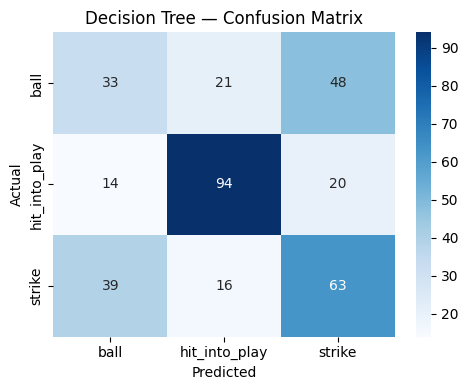

0.5459770114942529

In [14]:
# ── Decision Tree ────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_SEED)
dt_clf.fit(X_train, y_train, sample_weight=w_train)
y_pred_dt = dt_clf.predict(X_test)
evaluate('Decision Tree', y_test, y_pred_dt)

### 5b. Random Forest


── Random Forest ──────────────────────────────────────────
Accuracy: 0.5546
               precision    recall  f1-score   support

         ball       0.40      0.35      0.38       102
hit_into_play       0.79      0.79      0.79       128
       strike       0.43      0.47      0.45       118

     accuracy                           0.55       348
    macro avg       0.54      0.54      0.54       348
 weighted avg       0.55      0.55      0.55       348



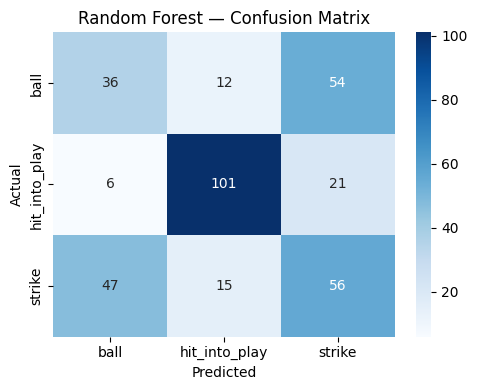

0.5545977011494253

In [15]:
# ── Random Forest ────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=RANDOM_SEED)
rf_clf.fit(X_train, y_train, sample_weight=w_train)
y_pred_rf = rf_clf.predict(X_test)
evaluate('Random Forest', y_test, y_pred_rf)

### 5c. Artificial Neural Network (ANN)

In [16]:
# ── ANN Architecture & Training ──────────────────────────────────────────────
import tensorflow as tf
from keras.utils import to_categorical

X_train_ann  = np.asarray(X_train).astype('float32')
y_train_cat  = to_categorical(y_train.astype('float32'), num_classes=3)
w_train_ann  = w_train.astype('float32')

ann = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8,  activation='relu'),
    tf.keras.layers.Dense(3,  activation='softmax'),   # 3 output classes
])
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = ann.fit(
    X_train_ann, y_train_cat,
    sample_weight=w_train_ann,
    batch_size=min(100, len(X_train_ann)),
    epochs=200, validation_split=0.1, verbose=0,
)
print('ANN training complete.')

ANN training complete.


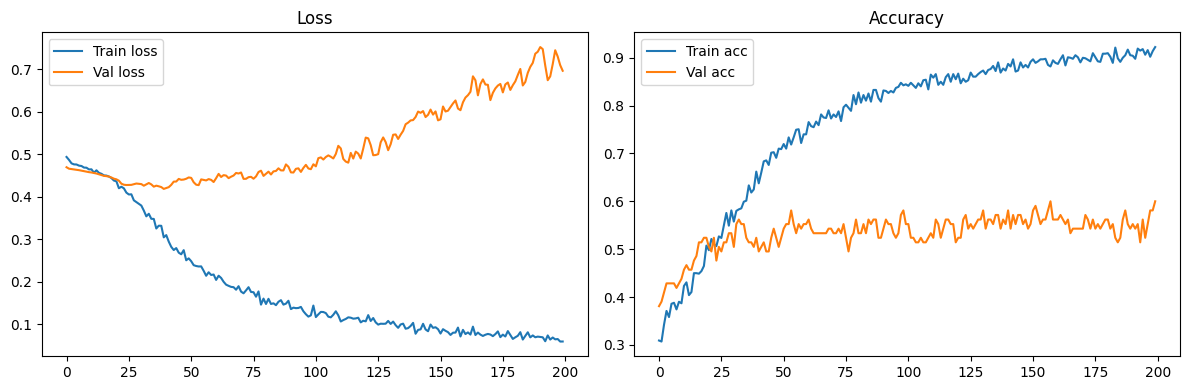

In [17]:
# ── ANN Training Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()


── ANN ──────────────────────────────────────────
Accuracy: 0.5776
               precision    recall  f1-score   support

         ball       0.39      0.31      0.35       102
hit_into_play       0.79      0.80      0.79       128
       strike       0.49      0.57      0.53       118

     accuracy                           0.58       348
    macro avg       0.56      0.56      0.56       348
 weighted avg       0.57      0.58      0.57       348



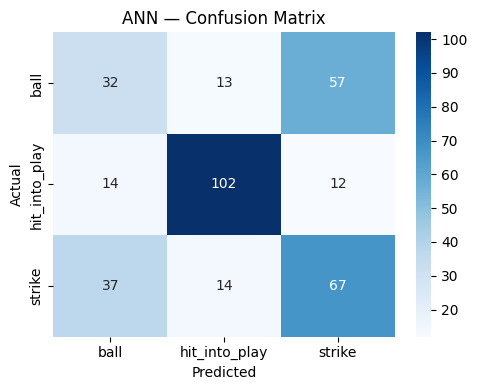

0.5775862068965517

In [18]:
# ── ANN Test-Set Evaluation ──────────────────────────────────────────────────
X_test_ann  = np.asarray(X_test).astype('float32')
y_pred_ann  = np.argmax(ann.predict(X_test_ann, verbose=0), axis=1)
evaluate('ANN', y_test, y_pred_ann)

### 5d. XGBoost


── XGBoost ──────────────────────────────────────────
Accuracy: 0.5776
               precision    recall  f1-score   support

         ball       0.38      0.28      0.33       102
hit_into_play       0.85      0.77      0.81       128
       strike       0.47      0.62      0.53       118

     accuracy                           0.58       348
    macro avg       0.57      0.56      0.56       348
 weighted avg       0.58      0.58      0.57       348



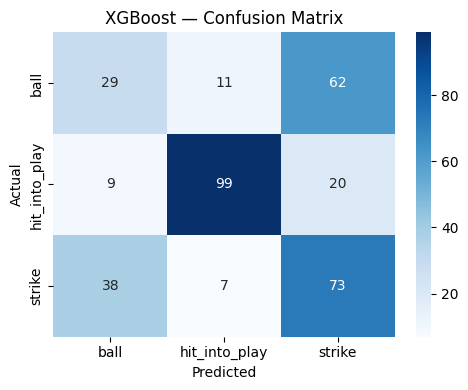

0.5775862068965517

In [19]:
# ── XGBoost Classifier ───────────────────────────────────────────────────────
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    objective='multi:softmax', num_class=3,
    random_state=RANDOM_SEED, verbosity=0,
)
xgb_clf.fit(X_train, y_train, sample_weight=w_train)
y_pred_xgb = xgb_clf.predict(X_test)
evaluate('XGBoost', y_test, y_pred_xgb)

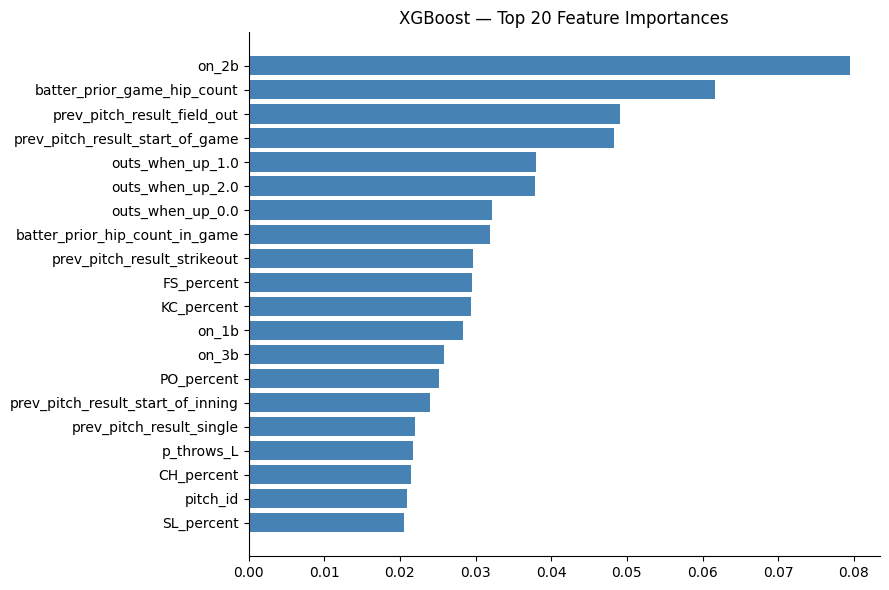

In [20]:
# ── XGBoost Feature Importance (Top 20) ──────────────────────────────────────
import pandas as pd

try:
    ohe_names = ct.named_transformers_['encoder'].get_feature_names_out(CATEGORICAL_COLS)
    pass_cols  = [c for c in X_raw.columns if c not in CATEGORICAL_COLS]
    feat_names = list(ohe_names) + pass_cols
    imp_df = (pd.DataFrame({'feature': feat_names,
                            'importance': xgb_clf.feature_importances_})
              .sort_values('importance', ascending=False).head(20))
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue')
    ax.set_title('XGBoost — Top 20 Feature Importances')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Feature importance plot skipped: {e}')

### 5e. LightGBM


── LightGBM ──────────────────────────────────────────
Accuracy: 0.5690
               precision    recall  f1-score   support

         ball       0.38      0.31      0.34       102
hit_into_play       0.86      0.74      0.79       128
       strike       0.47      0.60      0.53       118

     accuracy                           0.57       348
    macro avg       0.57      0.55      0.55       348
 weighted avg       0.58      0.57      0.57       348



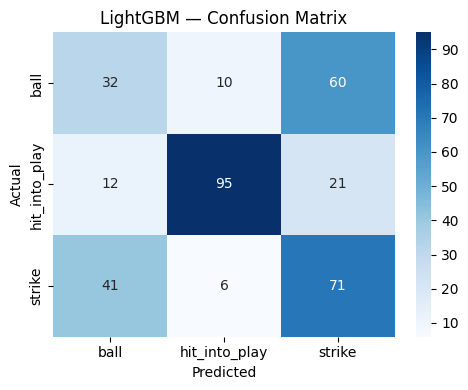

0.5689655172413793

In [21]:
# ── LightGBM Classifier ──────────────────────────────────────────────────────
import lightgbm as lgb

lgbm_clf = lgb.LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True, random_state=RANDOM_SEED, verbose=-1,
)
lgbm_clf.fit(X_train, y_train, sample_weight=w_train)
y_pred_lgbm = lgbm_clf.predict(X_test)
evaluate('LightGBM', y_test, y_pred_lgbm)

### 5f. CatBoost


── CatBoost ──────────────────────────────────────────
Accuracy: 0.5776
               precision    recall  f1-score   support

         ball       0.41      0.34      0.37       102
hit_into_play       0.84      0.77      0.80       128
       strike       0.47      0.58      0.52       118

     accuracy                           0.58       348
    macro avg       0.57      0.56      0.56       348
 weighted avg       0.59      0.58      0.58       348



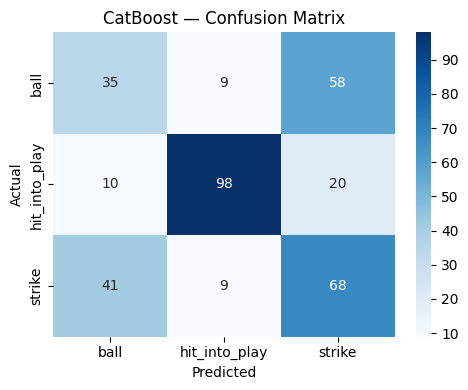

0.5775862068965517

In [22]:
# ── CatBoost Classifier ──────────────────────────────────────────────────────
from catboost import CatBoostClassifier

cat_clf = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    random_seed=RANDOM_SEED, verbose=0,
)
cat_clf.fit(X_train, y_train, sample_weight=w_train)
y_pred_cat = cat_clf.predict(X_test).flatten()
evaluate('CatBoost', y_test, y_pred_cat)

## 6. Model Comparison

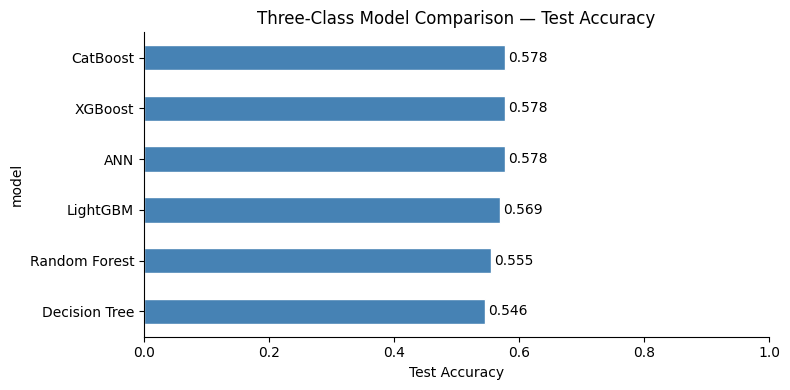

               accuracy
model                  
ANN              0.5776
XGBoost          0.5776
CatBoost         0.5776
LightGBM         0.5690
Random Forest    0.5546
Decision Tree    0.5460


In [23]:
# ── Side-by-Side Model Performance Chart ─────────────────────────────────────
import matplotlib.pyplot as plt

results_df = pd.DataFrame(test_results).set_index('model')
fig, ax = plt.subplots(figsize=(8, 4))
results_df['accuracy'].sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_xlim(0, 1)
ax.set_xlabel('Test Accuracy')
ax.set_title('Three-Class Model Comparison — Test Accuracy')
ax.spines[['top','right']].set_visible(False)
for i, v in enumerate(results_df['accuracy'].sort_values()):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout(); plt.show()
print(results_df.sort_values('accuracy', ascending=False).round(4))

## 7. Validation Study — All-Model Generalization

All six classifiers are evaluated on a **held-out validation window** entirely outside the training period. The same `ct` encoder and `sc` scaler fitted on training data are applied — no re-fitting on validation data.

In [24]:
# ── Load Validation Data ─────────────────────────────────────────────────────
VAL_START  = '2025-08-02'
VAL_END    = '2025-09-28'

table_validation = load_statcast(VAL_START, VAL_END)
table_full       = load_statcast(TRAIN_START, VAL_END)

table_validation['pitch_id'] = table_validation.index
table_full['pitch_id']       = table_full.index

# Load context sidecars
VAL_CONTEXT  = f'statcast_{VAL_START.replace("-","")}_{VAL_END.replace("-","")}_context_features.parquet'
FULL_CONTEXT = f'statcast_{TRAIN_START.replace("-","")}_{VAL_END.replace("-","")}_context_features.parquet'

if os.path.exists(VAL_CONTEXT):
    ctx_val = pd.read_parquet(VAL_CONTEXT)
    table_validation = table_validation.drop(columns=[c for c in CONTEXT_COLS if c in table_validation.columns], errors='ignore')
    table_validation = table_validation.merge(ctx_val, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table_validation.columns:
            table_validation[col] = table_validation[col].fillna(0).astype(int)
        else:
            table_validation[col] = 0
    print(f'Validation context features loaded.')
else:
    print(f'WARNING: {VAL_CONTEXT} not found.')
    for col in CONTEXT_COLS:
        table_validation[col] = 0

if os.path.exists(FULL_CONTEXT):
    ctx_full = pd.read_parquet(FULL_CONTEXT)
    table_full = table_full.drop(columns=[c for c in CONTEXT_COLS if c in table_full.columns], errors='ignore')
    table_full = table_full.merge(ctx_full, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table_full.columns:
            table_full[col] = table_full[col].fillna(0).astype(int)
        else:
            table_full[col] = 0
    print(f'Full dataset context features loaded.')
else:
    print(f'WARNING: {FULL_CONTEXT} not found.')
    for col in CONTEXT_COLS:
        table_full[col] = 0

table_validation['pitch_id'] = table_validation.index
table_full['pitch_id']       = table_full.index

print(f'Validation pitches : {len(table_validation):,}')
print(f'Full dataset size  : {len(table_full):,}')

Loading from cache: statcast_20250802_20250928.parquet  (36.1 MB)
Loaded 230,144 pitches  (2025-08-02 → 2025-09-28)
Loading from cache: statcast_20240328_20250928.parquet  (202.7 MB)
Loaded 1,480,626 pitches  (2024-03-28 → 2025-09-28)
Validation context features loaded.
Full dataset context features loaded.
Validation pitches : 230,144
Full dataset size  : 1,480,626


In [25]:
# ── Build Validation Batter Matrix ───────────────────────────────────────────
first_pitch_validation = table_validation[
    (table_validation['balls'] == 0) & (table_validation['strikes'] == 0)
]
first_pitch_full = table_full[
    (table_full['balls'] == 0) & (table_full['strikes'] == 0)
]

batter_validation = first_pitch_validation[
    first_pitch_validation['batter'] == hitter_id
].copy()

new_batter_val = batter_validation.drop('events', axis=1).copy()
new_batter_val['description'] = new_batter_val['description'].replace(
    {o: 'strike' for o in STRIKE_OUTCOMES}
)
new_batter_val['description'] = new_batter_val['description'].replace(
    {o: 'ball' for o in BALL_OUTCOMES}
)

batter_val_clean = (
    new_batter_val
    .drop(columns=DROP_COLS_1, errors='ignore')
    .drop(columns=DROP_COLS_2, errors='ignore')
    .drop(columns=DROP_COLS_3, errors='ignore')
)
for base_col in ['on_1b', 'on_2b', 'on_3b']:
    batter_val_clean[base_col] = batter_val_clean[base_col].fillna(0)
    batter_val_clean.loc[batter_val_clean[base_col] > 0, base_col] = 1

# Ensure context columns present
for ctx_col in CONTEXT_COLS:
    if ctx_col not in batter_val_clean.columns:
        if ctx_col in table_validation.columns:
            batter_val_clean = batter_val_clean.merge(
                table_validation[['pitch_id', ctx_col]].drop_duplicates('pitch_id'),
                on='pitch_id', how='left'
            )
            batter_val_clean[ctx_col] = batter_val_clean[ctx_col].fillna(0).astype(int)
        else:
            batter_val_clean[ctx_col] = 0

print(f'Validation batter matrix: {batter_val_clean.shape}')

Validation batter matrix: (178, 19)


In [26]:
# ── Build Validation Pitcher Features (from full dataset) ────────────────────
val_pitchers = new_batter_val['pitcher'].unique()
pitchers_val = pd.DataFrame(val_pitchers, columns=['pitcher'])
for col in ['strike_percent','swing_percent_on_strikes',
            'contact_percent_on_strikes','in_play_percent_on_strikes']:
    pitchers_val[col] = 0.0
for pt in PITCH_TYPES:
    pitchers_val[f'{pt}_percent'] = 0.0

for i in range(len(pitchers_val)):
    pid = pitchers_val['pitcher'].iloc[i]
    sel = first_pitch_full[first_pitch_full['pitcher'] == pid]
    c   = compute_pitch_counts(sel['description'])
    total_p   = sum(c.values())
    t_strikes = (c['called_strike'] + c['swinging_strike'] + c['foul'] +
                 c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] +
                 c['swinging_strike_blocked'] + c['missed_bunt'] +
                 c['bunt_foul_tip'] + c['automatic_strike'])
    t_contact = c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip']
    t_swings  = (c['swinging_strike'] + c['swinging_strike_blocked'] +
                 c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip'])
    if total_p > 0:
        pitchers_val.at[i, 'strike_percent'] = t_strikes / total_p
        if t_strikes > 0:
            pitchers_val.at[i, 'swing_percent_on_strikes']  = t_swings  / t_strikes
            pitchers_val.at[i, 'contact_percent_on_strikes'] = t_contact / t_strikes
            pitchers_val.at[i, 'in_play_percent_on_strikes'] = c['hit_into_play'] / t_strikes
    sel_pt   = sel['pitch_type'].fillna('None')
    pt_vc    = sel_pt.value_counts()
    total_pt = pt_vc.sum()
    if total_pt > 0:
        for pt in PITCH_TYPES:
            pitchers_val.at[i, f'{pt}_percent'] = pt_vc.get(pt, 0) / total_pt

print(f'Validation pitcher features: {pitchers_val.shape}')

Validation pitcher features: (94, 24)


In [27]:
# ── Validation Game-State Context ────────────────────────────────────────────
batters_val_merged = pd.merge(batter_val_clean, pitchers_val, on='pitcher', how='inner')
batters_val_merged = batters_val_merged.reset_index(drop=True).copy()
batters_val_merged['prev_pitch_result']   = 'start_of_game'
batters_val_merged['prev_ab_pitch_count'] = 0

for i in range(len(batter_val_clean)):
    select_id   = batter_val_clean['pitch_id'].iloc[i]
    select_game = batters_val_merged['game_pk'].iloc[i]
    select_inn  = batters_val_merged['inning'].iloc[i]
    select_top  = batters_val_merged['inning_topbot'].iloc[i]
    prev = table_validation[table_validation['pitch_id'] == (select_id + 1)]
    if prev.empty:
        batters_val_merged.at[i, 'prev_pitch_result'] = 'start_of_game'
        continue
    prev_game = prev['game_pk'].values[0]
    prev_inn  = prev['inning'].values[0]
    prev_top  = prev['inning_topbot'].values[0]
    if prev_game != select_game:
        batters_val_merged.at[i, 'prev_pitch_result'] = 'start_of_game'
    elif prev_inn != select_inn or prev_top != select_top:
        batters_val_merged.at[i, 'prev_pitch_result'] = 'start_of_inning'
    else:
        batters_val_merged.at[i, 'prev_pitch_result']   = prev['events'].values[0]
        batters_val_merged.at[i, 'prev_ab_pitch_count'] = prev['pitch_number'].values[0]

batters_val_merged['prev_pitch_result'] = batters_val_merged['prev_pitch_result'].replace(EVENT_MAP)
desc_col_val = batters_val_merged.pop('description')
batters_val_merged.insert(len(batters_val_merged.columns), 'description', desc_col_val)

print(f'Validation merged matrix: {batters_val_merged.shape}')

Validation merged matrix: (178, 44)


In [28]:
# ── Encode & Scale Validation Data ───────────────────────────────────────────
dataset_val = batters_val_merged.drop(columns=DROP_BEFORE_MODEL, errors='ignore')

y_val_raw = dataset_val['description']
X_val_raw = dataset_val.drop(columns=['description'])

# Use the SAME encoder and scaler fitted on training data
X_val    = ct.transform(X_val_raw)
le_val   = LabelEncoder()
y_val    = le_val.fit_transform(y_val_raw)
X_val_sc = sc.transform(X_val)

print(f'Validation feature matrix: {X_val_sc.shape}')
print(f'Validation classes       : {le_val.classes_}')

Validation feature matrix: (178, 51)
Validation classes       : ['ball' 'hit_into_play' 'strike']


### 7a. Decision Tree — Validation


── Decision Tree (Val) ──────────────────────────────────────────
Accuracy: 0.4270
               precision    recall  f1-score   support

         ball       0.43      0.35      0.39        74
hit_into_play       0.15      0.29      0.20        17
       strike       0.54      0.52      0.53        87

     accuracy                           0.43       178
    macro avg       0.37      0.39      0.37       178
 weighted avg       0.45      0.43      0.44       178



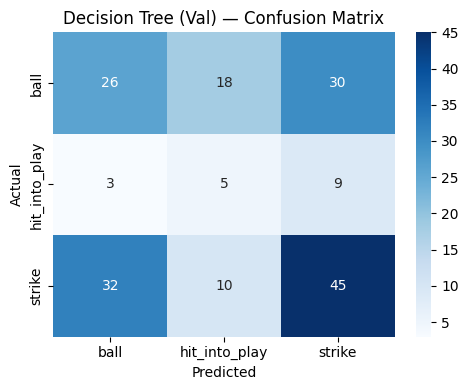

0.42696629213483145

In [29]:
# ── Decision Tree Validation ────────────────────────────────────────────────
y_pred_val_decision_tree = dt_clf.predict(X_val_sc)
evaluate('Decision Tree (Val)', y_val, y_pred_val_decision_tree)

### 7b. Random Forest — Validation


── Random Forest (Val) ──────────────────────────────────────────
Accuracy: 0.4494
               precision    recall  f1-score   support

         ball       0.45      0.43      0.44        74
hit_into_play       0.11      0.12      0.11        17
       strike       0.52      0.53      0.53        87

     accuracy                           0.45       178
    macro avg       0.36      0.36      0.36       178
 weighted avg       0.45      0.45      0.45       178



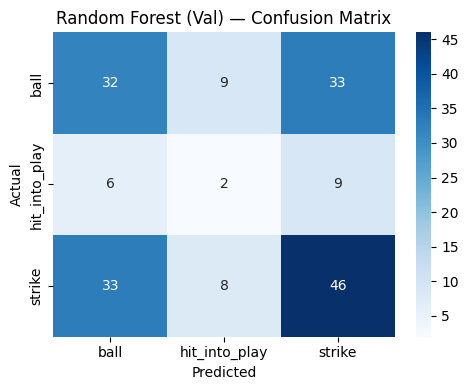

0.449438202247191

In [30]:
# ── Random Forest Validation ────────────────────────────────────────────────
y_pred_val_random_forest = rf_clf.predict(X_val_sc)
evaluate('Random Forest (Val)', y_val, y_pred_val_random_forest)

### 7c. XGBoost — Validation


── XGBoost (Val) ──────────────────────────────────────────
Accuracy: 0.4045
               precision    recall  f1-score   support

         ball       0.36      0.30      0.33        74
hit_into_play       0.14      0.18      0.15        17
       strike       0.49      0.54      0.52        87

     accuracy                           0.40       178
    macro avg       0.33      0.34      0.33       178
 weighted avg       0.40      0.40      0.40       178



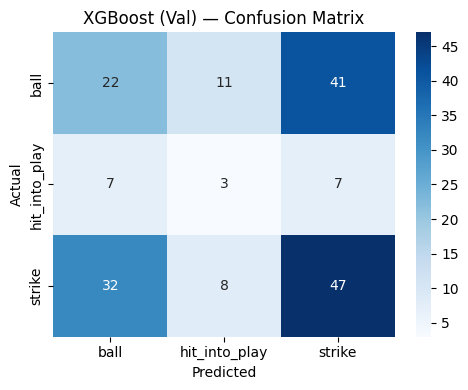

0.4044943820224719

In [31]:
# ── XGBoost Validation ────────────────────────────────────────────────
y_pred_val_xgboost = xgb_clf.predict(X_val_sc)
evaluate('XGBoost (Val)', y_val, y_pred_val_xgboost)

### 7d. LightGBM — Validation


── LightGBM (Val) ──────────────────────────────────────────
Accuracy: 0.4157
               precision    recall  f1-score   support

         ball       0.37      0.30      0.33        74
hit_into_play       0.07      0.06      0.06        17
       strike       0.49      0.59      0.53        87

     accuracy                           0.42       178
    macro avg       0.31      0.31      0.31       178
 weighted avg       0.40      0.42      0.40       178



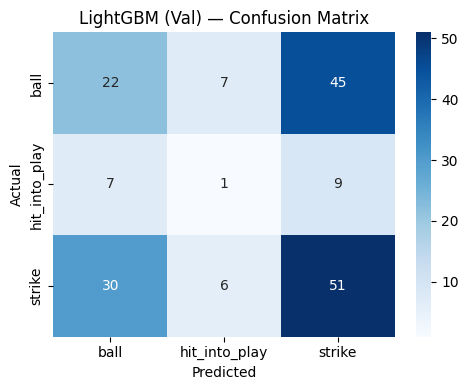

0.4157303370786517

In [32]:
# ── LightGBM Validation ────────────────────────────────────────────────
y_pred_val_lightgbm = lgbm_clf.predict(X_val_sc)
evaluate('LightGBM (Val)', y_val, y_pred_val_lightgbm)

### 7e. CatBoost — Validation


── CatBoost (Val) ──────────────────────────────────────────
Accuracy: 0.4326
               precision    recall  f1-score   support

         ball       0.38      0.35      0.37        74
hit_into_play       0.14      0.06      0.08        17
       strike       0.49      0.57      0.53        87

     accuracy                           0.43       178
    macro avg       0.34      0.33      0.33       178
 weighted avg       0.41      0.43      0.42       178



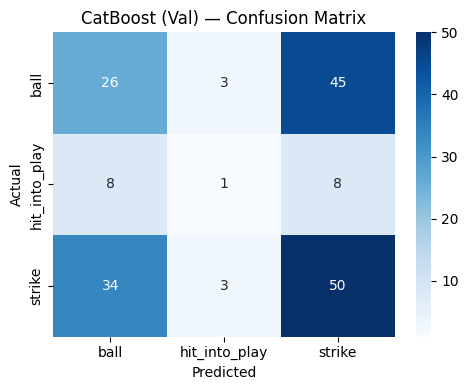

0.43258426966292135

In [33]:
# ── CatBoost Validation ────────────────────────────────────────────────
y_pred_val_catboost = cat_clf.predict(X_val_sc).flatten()
evaluate('CatBoost (Val)', y_val, y_pred_val_catboost)

### 7f. ANN — Validation


── ANN (Val) ──────────────────────────────────────────
Accuracy: 0.4494
               precision    recall  f1-score   support

         ball       0.44      0.49      0.46        74
hit_into_play       0.11      0.06      0.08        17
       strike       0.49      0.49      0.49        87

     accuracy                           0.45       178
    macro avg       0.35      0.35      0.34       178
 weighted avg       0.43      0.45      0.44       178



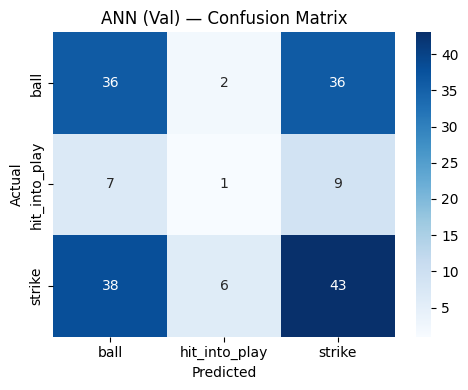

0.449438202247191

In [34]:
# ── ANN Validation ───────────────────────────────────────────────────────────
X_val_ann = np.asarray(X_val_sc).astype('float32')
y_pred_val_ann = np.argmax(ann.predict(X_val_ann, verbose=0), axis=1)
evaluate('ANN (Val)', y_val, y_pred_val_ann)

## 8. Full Validation Summary — All Models

Test-set performance is paired with validation performance to assess generalization gap.

In [35]:
# ── Build Paired Test vs. Validation Summary Table ──────────────────────────
val_results = [
    {'model': 'Decision Tree', 'val_accuracy': accuracy_score(y_val, y_pred_val_decision_tree)},
    {'model': 'Random Forest', 'val_accuracy': accuracy_score(y_val, y_pred_val_random_forest)},
    {'model': 'XGBoost',       'val_accuracy': accuracy_score(y_val, y_pred_val_xgboost)},
    {'model': 'LightGBM',      'val_accuracy': accuracy_score(y_val, y_pred_val_lightgbm)},
    {'model': 'CatBoost',      'val_accuracy': accuracy_score(y_val, y_pred_val_catboost)},
    {'model': 'ANN',           'val_accuracy': accuracy_score(y_val, y_pred_val_ann)},
]

test_df = pd.DataFrame(test_results).set_index('model')
val_df  = pd.DataFrame(val_results).set_index('model')
summary = test_df.join(val_df, how='outer')
summary['gap'] = summary['accuracy'] - summary['val_accuracy']

print('Test vs. Validation Accuracy:')
print(summary.round(4).to_string())

Test vs. Validation Accuracy:
                     accuracy  val_accuracy     gap
model                                              
ANN                    0.5776        0.4494  0.1281
ANN (Val)              0.4494           NaN     NaN
CatBoost               0.5776        0.4326  0.1450
CatBoost (Val)         0.4326           NaN     NaN
Decision Tree          0.5460        0.4270  0.1190
Decision Tree (Val)    0.4270           NaN     NaN
LightGBM               0.5690        0.4157  0.1532
LightGBM (Val)         0.4157           NaN     NaN
Random Forest          0.5546        0.4494  0.1052
Random Forest (Val)    0.4494           NaN     NaN
XGBoost                0.5776        0.4045  0.1731
XGBoost (Val)          0.4045           NaN     NaN


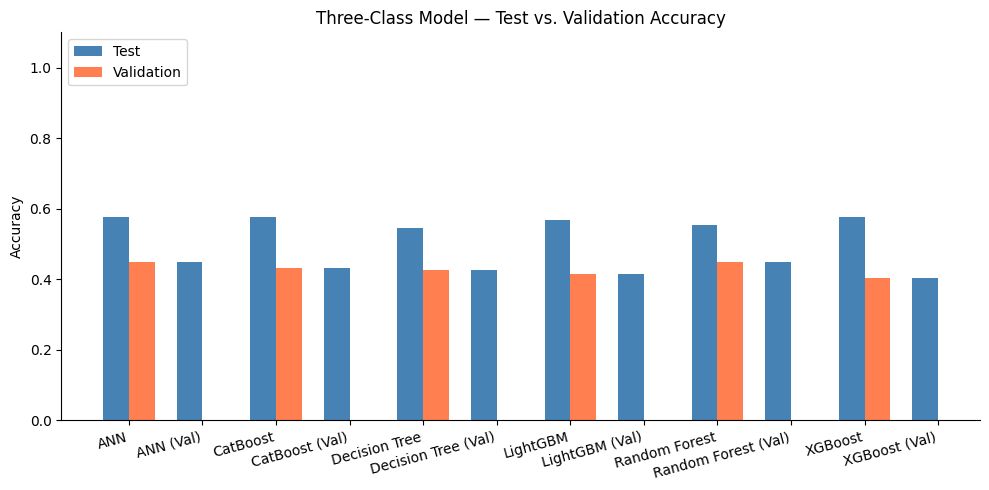

In [36]:
# ── Grouped Bar Chart: Test vs. Validation for Every Model ──────────────────
x      = np.arange(len(summary))
width  = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, summary['accuracy'],     width, label='Test',       color='steelblue')
ax.bar(x + width/2, summary['val_accuracy'], width, label='Validation', color='coral')
ax.set_xticks(x); ax.set_xticklabels(summary.index, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Three-Class Model — Test vs. Validation Accuracy')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

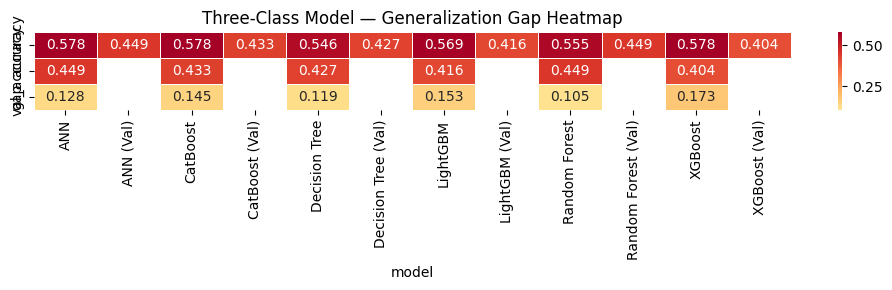

In [37]:
# ── Generalization Gap Heatmap ────────────────────────────────────────────────
import seaborn as sns

gap_data = summary[['accuracy', 'val_accuracy', 'gap']].T
fig, ax  = plt.subplots(figsize=(10, 3))
sns.heatmap(gap_data, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, center=0)
ax.set_title('Three-Class Model — Generalization Gap Heatmap')
plt.tight_layout(); plt.show()